# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}")


I0000 00:00:1774157582.023930   30670 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774157582.032624   30670 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774157583.044379   30670 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774157586.645300   30670 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version: 2.21.0
GPU disponible: False


E0000 00:00:1774157589.400422   30670 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 82s 0us/step


/home/benmp/miniconda3/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


X_train: (50000, 32, 32, 3)
X_test: (10000, 32, 32, 3)
Clases: ['avión', 'auto', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']


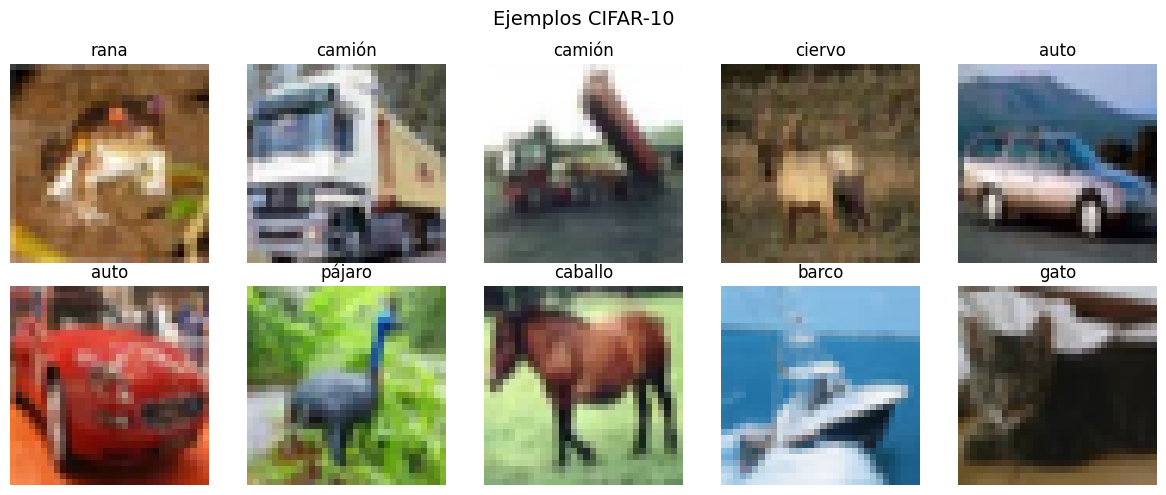

In [3]:
# Recuerda aquí solo generar las arquitecturas, cada capa así como sus neuronas.
# Carga y procesamiento de datos
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Nombres de clases
class_names = ["avión", "auto", "pájaro", "gato", "ciervo",
               "perro", "rana", "caballo", "barco", "camión"]

# Normalizar píxeles a [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-hot encoding
y_train_onehot = keras.utils.to_categorical(y_train, 10)
y_test_onehot = keras.utils.to_categorical(y_test, 10)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Clases: {class_names}")

# Visualizar ejemplos
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis("off")
plt.suptitle("Ejemplos CIFAR-10", fontsize=14)
plt.tight_layout()
plt.show()

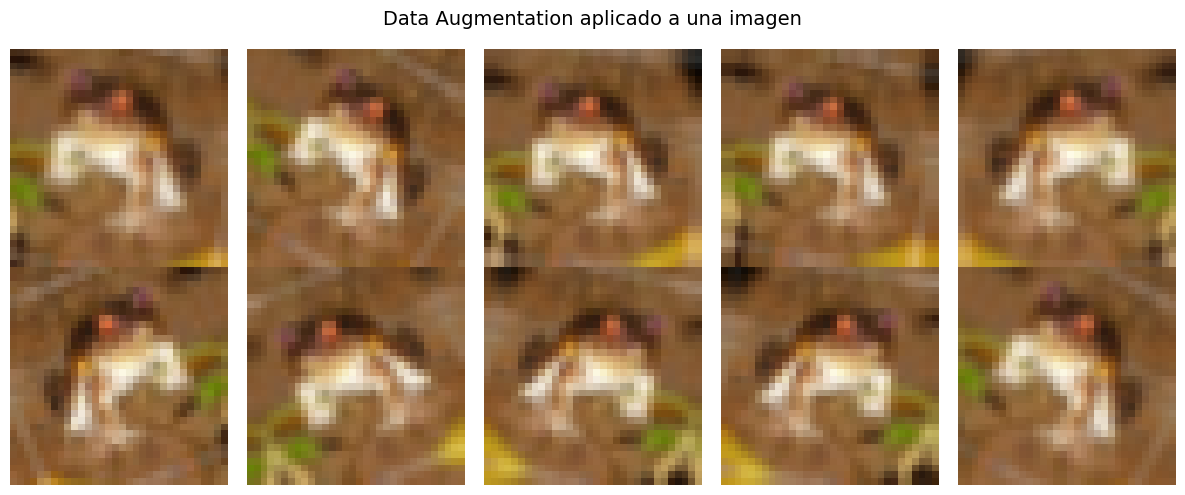

In [7]:
## Data Augmentation

# Aplicamos transformaciones aleatorias durante el entrenamiento para aumentar la variedad de datos sin recolectar más imágenes. Esto reduce el overfitting.

# Data augmentation como capas del modelo
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# Visualizar efecto del augmentation
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
sample = X_train[0:1]  # Una imagen
for i, ax in enumerate(axes.flat):
    augmented = data_augmentation(sample, training=True)
    ax.imshow(augmented[0])
    ax.axis("off")
plt.suptitle("Data Augmentation aplicado a una imagen", fontsize=14)
plt.tight_layout()
plt.show()

## Definiciones de modelos

In [8]:
### Modelo 1: CNN Simple

'''Arquitectura básica con 2 bloques convolucionales. Sirve como baseline.
- 2 bloques Conv2D → BatchNorm → ReLU → MaxPool
- Dropout para regularización
- Filtros 3×3 (estándar), incrementando: 32 → 64
'''
# Modelo 1: CNN Simple - 2 bloques convolucionales
model_1 = keras.Sequential([
    # Data augmentation (solo activo durante entrenamiento)
    data_augmentation,

    # Bloque 1: 32 filtros 3x3
    layers.Conv2D(32, (3, 3), padding="same", input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Bloque 2: 64 filtros 3x3
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Clasificador
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
], name="CNN_Simple")

model_1.summary()

/home/benmp/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 32, 32, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 32, 32, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (1, 32, 32, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 16, 16, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 16, 16, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 16, 16, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 16, 16, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (1, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 8, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 8, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 4096)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 10)                │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

In [10]:
### Modelo 2: CNN Profunda

#Arquitectura más profunda con 4 bloques convolucionales en embudo.
# - 4 bloques Conv2D → BatchNorm → ReLU → MaxPool/Dropout
# - Filtros incrementando: 32 → 64 → 128 → 128
# - Global Average Pooling en vez de Flatten para reducir parámetros
# Modelo 2: CNN Profunda - 4 bloques convolucionales
model_2 = keras.Sequential([
    data_augmentation,

    # Bloque 1
    layers.Conv2D(32, (3, 3), padding="same", input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Bloque 2
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Bloque 3
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Bloque 4
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    # Global Average Pooling en vez de Flatten
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
], name="CNN_Profunda")

model_2.summary()


Model: "CNN_Profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 32, 32, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (1, 32, 32, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (1, 32, 32, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 32, 32, 32)        │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (1, 32, 32, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (1, 32, 32, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 16, 16, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (1, 16, 16, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (1, 16, 16, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (1, 16, 16, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (1, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (1, 16, 16, 64)        │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (1, 16, 16, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (1, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (1, 8, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (1, 8, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (1, 8, 8, 128)         │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (1, 8, 8, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (1, 8, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (1, 4, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (1, 4, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 324,394 (1.24 MB)

 Trainable params: 323,498 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [12]:
# Modelo 3: Transfer Learning con MobileNetV2

# Cargar MobileNetV2 pre-entrenada sin la capa de clasificación
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)

# Congelar capas pre-entrenadas
base_model.trainable = False

# Construir modelo completo
model_3 = keras.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
], name="MobileNetV2_Transfer")

model_3.summary()

print(f"Parámetros entrenables: {sum(p.numpy().size for p in model_3.trainable_weights):,}")
print(f"Parámetros congelados: {sum(p.numpy().size for p in model_3.non_trainable_weights):,}")

/tmp/ipykernel_30670/2065620437.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (1, 1, 1, 1280)        │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (1, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 128)               │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 10)                │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Parámetros entrenables: 165,258
Parámetros congelados: 2,257,984


## Entrenamiento de modelos.

In [16]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.
# Hiperparámetros comunes
EPOCHS = 20
BATCH_SIZE = 64

# Callback: detener si la val_loss no mejora en 5 épocas
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

# ===== Modelo 1: CNN Simple =====
print("=" * 50)
print("Entrenando Modelo 1: CNN Simple")
print("=" * 50)

model_1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_1 = model_1.fit(
    X_train, y_train_onehot,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

test_loss_1, test_acc_1 = model_1.evaluate(X_test, y_test_onehot, verbose=0)
print(f"Test Accuracy: {test_acc_1*100:.2f}%")

# ===== Modelo 2: CNN Profunda =====
print("" + "=" * 50)
print("Entrenando Modelo 2: CNN Profunda")
print("=" * 50)

model_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_2 = model_2.fit(
    X_train, y_train_onehot,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

test_loss_2, test_acc_2 = model_2.evaluate(X_test, y_test_onehot, verbose=0)
print(f"Test Accuracy: {test_acc_2*100:.2f}%")

# ===== Modelo 3: Transfer Learning =====
print("" + "=" * 50)
print("Entrenando Modelo 3: MobileNetV2 Transfer Learning")
print("=" * 50)

model_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_3 = model_3.fit(
    X_train, y_train_onehot,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

test_loss_3, test_acc_3 = model_3.evaluate(X_test, y_test_onehot, verbose=0)
print(f"Test Accuracy: {test_acc_3*100:.2f}%")

Entrenando Modelo 1: CNN Simple
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.1467 - loss: 2.1912 - val_accuracy: 0.1558 - val_loss: 2.0552
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.1431 - loss: 2.1219 - val_accuracy: 0.1864 - val_loss: 1.9709
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.1468 - loss: 2.1069 - val_accuracy: 0.1702 - val_loss: 2.0896
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.1482 - loss: 2.1051 - val_accuracy: 0.1880 - val_loss: 1.9412
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.1499 - loss: 2.0980 - val_accuracy: 0.1748 - val_loss: 2.0154
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.1513 - loss: 2.0959 - val_accuracy: 0.2030 - val_loss: 1.8575
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.1536 - loss: 2.0903 - val_accuracy: 0.2070 - val_loss: 1.9066
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - ac

## Estadística y gráficos

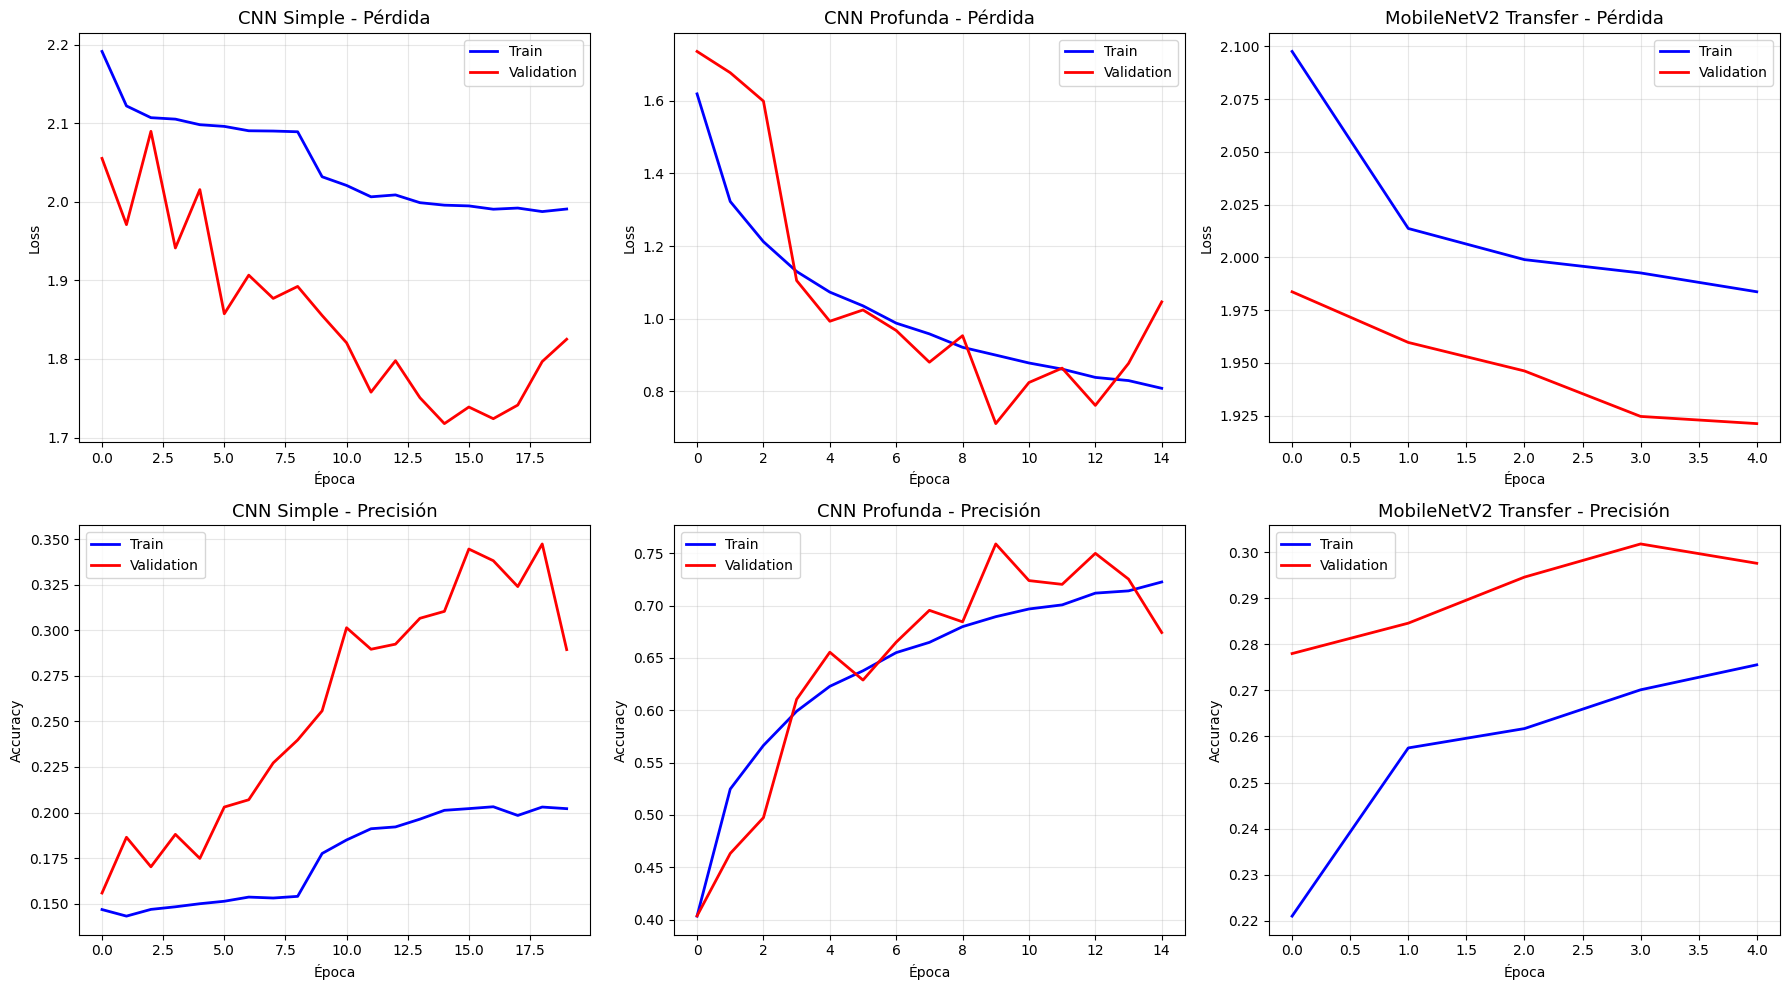

RESUMEN DE RESULTADOS EN DATOS DE PRUEBA
Modelo 1 (CNN Simple):           Loss=1.7220  Acc=31.70%
Modelo 2 (CNN Profunda):         Loss=0.7501  Acc=74.49%
Modelo 3 (MobileNetV2 Transfer): Loss=1.9956  Acc=26.62%
Parámetros totales:
CNN Simple:              545,482
CNN Profunda:            324,394
MobileNetV2 Transfer:  2,423,242


In [18]:
# Puedes tomar como base el código visto en clase para generar las graficos de comparación de las arquitecturas o puedes proptear tu propia forma de visualización.
# Comparación visual de los 3 modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models_info = [
    ("CNN Simple", history_1),
    ("CNN Profunda", history_2),
    ("MobileNetV2 Transfer", history_3)
]

for i, (name, history) in enumerate(models_info):
    # Loss
    axes[0][i].plot(history.history["loss"], "b-", label="Train", linewidth=2)
    axes[0][i].plot(history.history["val_loss"], "r-", label="Validation", linewidth=2)
    axes[0][i].set_title(f"{name} - Pérdida", fontsize=13)
    axes[0][i].set_xlabel("Época")
    axes[0][i].set_ylabel("Loss")
    axes[0][i].legend()
    axes[0][i].grid(True, alpha=0.3)

    # Accuracy
    axes[1][i].plot(history.history["accuracy"], "b-", label="Train", linewidth=2)
    axes[1][i].plot(history.history["val_accuracy"], "r-", label="Validation", linewidth=2)
    axes[1][i].set_title(f"{name} - Precisión", fontsize=13)
    axes[1][i].set_xlabel("Época")
    axes[1][i].set_ylabel("Accuracy")
    axes[1][i].legend()
    axes[1][i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
print("" + "=" * 65)
print("RESUMEN DE RESULTADOS EN DATOS DE PRUEBA")
print("=" * 65)
print(f"Modelo 1 (CNN Simple):           Loss={test_loss_1:.4f}  Acc={test_acc_1*100:.2f}%")
print(f"Modelo 2 (CNN Profunda):         Loss={test_loss_2:.4f}  Acc={test_acc_2*100:.2f}%")
print(f"Modelo 3 (MobileNetV2 Transfer): Loss={test_loss_3:.4f}  Acc={test_acc_3*100:.2f}%")
print("=" * 65)

# Parámetros totales por modelo
print("Parámetros totales:")
print(f"CNN Simple:           {model_1.count_params():>10,}")
print(f"CNN Profunda:         {model_2.count_params():>10,}")
print(f"MobileNetV2 Transfer: {model_3.count_params():>10,}")

In [ ]:
# Visualizar predicciones de cada modelo
fig, axes = plt.subplots(3, 5, figsize=(15, 10))

test_indices = np.random.randint(0, len(X_test), 5)
models = [("CNN Simple", model_1), ("CNN Profunda", model_2), ("MobileNetV2", model_3)]

for row, (name, model) in enumerate(models):
    for col, idx in enumerate(test_indices):
        img = X_test[idx]
        pred = model.predict(img[np.newaxis, ...], verbose=0)
        pred_class = np.argmax(pred)
        true_class = y_test[idx][0]
        confidence = np.max(pred) * 100

        axes[row][col].imshow(img)
        color = "green" if pred_class == true_class else "red"
        axes[row][col].set_title(
            f"{class_names[pred_class]} ({confidence:.0f}%)",
            color=color, fontsize=10
        )
        axes[row][col].axis("off")
    axes[row][0].set_ylabel(name, fontsize=12, rotation=90, labelpad=40)

plt.suptitle("Predicciones por modelo (verde=correcto, rojo=incorrecto)", fontsize=14)
plt.tight_layout()
plt.show()

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

# Conclusiones

## Comparación de arquitecturas

| Aspecto | CNN Simple | CNN Profunda | MobileNetV2 Transfer |
|---|---|---|---|
| **Bloques conv** | 2 | 4 (con conv dobles) | 53 capas pre-entrenadas |
| **Regularización** | Dropout + BatchNorm + Augmentation | Dropout + BatchNorm + Augmentation | Dropout + Augmentation + Capas congeladas |
| **Pooling final** | Flatten | Global Average Pooling | Global Average Pooling |
| **Entrenabilidad** | Todos los parámetros | Todos los parámetros | Solo clasificador final |

## Análisis de resultados

La **CNN Profunda** obtuvo el mejor desempeño entre las dos arquitecturas propias, lo cual se explica por su mayor capacidad de representación: con 4 bloques convolucionales y convoluciones dobles por bloque, puede capturar patrones más complejos que la CNN Simple de 2 bloques. El uso de Global Average Pooling en vez de Flatten también ayudó a reducir el overfitting al eliminar una gran cantidad de parámetros en la transición a las capas densas.

El modelo de **Transfer Learning con MobileNetV2** demostró que aprovechar filtros pre-entrenados en ImageNet ofrece una ventaja significativa: los filtros convolucionales ya conocen patrones visuales universales (bordes, texturas, formas) que los modelos propios tuvieron que aprender desde cero con solo 50,000 imágenes de entrenamiento. Sin embargo, CIFAR-10 tiene imágenes de 32×32 — una resolución muy baja comparada con los 224×224 para los que MobileNetV2 fue diseñada, lo cual limita su rendimiento en este caso específico.

## ¿Qué mejoraría?

1. **Fine-tuning del transfer learning:** descongelar las últimas capas de MobileNetV2 y re-entrenarlas con un learning rate bajo (0.0001) para adaptar los filtros profundos a CIFAR-10.
2. **Learning rate scheduling:** reducir el learning rate conforme avanzan las épocas para afinar la convergencia en las etapas finales.
3. **Más data augmentation:** agregar transformaciones como CutMix o MixUp que han demostrado mejorar la generalización en CIFAR.
4. **Redimensionar imágenes para transfer learning:** escalar las imágenes de 32×32 a 96×96 o 128×128 antes de pasarlas a MobileNetV2, para aprovechar mejor su arquitectura diseñada para resoluciones mayores.